# S&P 500 Equity Option Analytics: Temporal Features (GARCH)

**Chapter 9: Model-Based Feature Extraction**
**Section Reference**: 9.3 - Volatility Features

This notebook fits GJR-GARCH(1,1) per stock to produce forward-looking
conditional volatility estimates. The primary contribution is an alternative
VRP feature: `garch_ivrv_spread = iv_30_atm - garch_cond_vol`.

## Role: Secondary Temporal Model

GARCH is assigned as a **secondary** model for this case study. The primary
value is in the options-derived features (Ch8), not temporal dynamics.
GARCH serves a specific, narrow role: replacing the VRP denominator with a
forward-looking realized vol estimate rather than a backward-looking one.

## Walk-Forward Protocol
- Fit GJR-GARCH on training window returns (per CV fold)
- Run variance recursion on full train+test window with frozen parameters
- No re-estimation within fold (use fitted parameters)

## Output Features (3)
- `garch_cond_vol`: 1-step-ahead conditional volatility (annualized)
- `garch_ivrv_spread`: IV minus GARCH forecast (forward-looking VRP)
- `garch_vol_surprise`: |return| / garch_cond_vol (news impact)

## Cross-References
- **Teaching**: [`08_garch_volatility`](../../09_model_based_features/08_garch_volatility.ipynb)
- **Upstream**: [`02_labels`](02_labels.ipynb) (label parquet files and canonical splits),
  `03_financial_features.py`
- **Downstream**: Ch11+ (ML models use combined features + temporal)

In [1]:
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import polars as pl
from arch import arch_model

from case_studies.utils.cv_window import modeling_fold_boundaries
from data import load_sp500_daily_bars
from utils.cv_splits import load_evaluation_config
from utils.paths import get_case_study_dir
from utils.style import ml4t_palette


def _normalize_symbol_column(df: pl.DataFrame) -> pl.DataFrame:
    if "symbol" in df.columns:
        return df
    msg = f"Expected symbol-like column in frame, found columns={df.columns}"
    raise KeyError(msg)

In [2]:
CASE_STUDY_ID = "sp500_equity_option_analytics"
MIN_OBS = 252  # Minimum observations for fitting (relaxed in TEST)
MAX_SYMBOLS = None  # Limit symbols in TEST mode
start_date = "2017-01-01"
end_date = "2021-12-31"

In [3]:
CASE_DIR = get_case_study_dir("sp500_equity_option_analytics")
LABELS_DIR = CASE_DIR / "labels"
FEATURES_DIR = CASE_DIR / "features"

# GARCH configuration
MIN_OBS = 252  # Minimum observations for fitting (relaxed in TEST)
MAX_SYMBOLS = None  # Limit symbols in TEST mode

## 1. Load Data

Load prices, CV config, and Ch8 features. We need:
- Prices for GARCH fitting (daily returns)
- Canonical label timeline for walk-forward fold boundaries
- Ch8 features for IV data (to compute garch_ivrv_spread)

In [4]:
# Load prices from canonical loader
prices = load_sp500_daily_bars(start_date=start_date, end_date=end_date)
print(f"Loaded prices: {prices.shape[0]:,} rows, {prices['symbol'].n_unique()} symbols")

prices = prices.sort(["symbol", "timestamp"])

Loaded prices: 635,703 rows, 638 symbols


In [5]:
# Resolve producer folds from the same label timeline and split generator used
# by every downstream model consumer.
canonical_splits = modeling_fold_boundaries(CASE_STUDY_ID, "fwd_ret_5d")
if not canonical_splits:
    raise RuntimeError("Canonical fwd_ret_5d modeling folds are unavailable")
evaluation_config = load_evaluation_config(CASE_STUDY_ID)
print(f"Canonical modeling folds: {len(canonical_splits)} validation splits")

Canonical modeling folds: 2 validation splits


In [6]:
# Load Ch8 features for IV data (needed for garch_ivrv_spread)
features_path = FEATURES_DIR / "financial.parquet"
if features_path.exists():
    ch8_features = _normalize_symbol_column(pl.read_parquet(features_path)).select(
        ["timestamp", "symbol", "iv_30_atm"]
    )
    print(f"Loaded Ch8 features: {ch8_features.shape[0]:,} rows")
    has_iv = True
else:
    print("Ch8 features not found - will compute garch_cond_vol only (no garch_ivrv_spread)")
    ch8_features = None
    has_iv = False

Loaded Ch8 features: 530,503 rows


## 2. Define Walk-Forward Fold Boundaries

GARCH is fitted on each fold's training window. For the test window,
we use the fitted model to generate 1-step-ahead conditional variance
forecasts without re-estimation.

**Note on holdout fold**: We include a third fold that covers the 2021 holdout
period. This is a deliberate deviation from the strict "sealed holdout" protocol:
GARCH fitting uses only training-window prices (no label leakage), so generating
conditional volatility features for the holdout window is methodologically safe.
Downstream Ch11+ notebooks expect temporal features to cover the full date range
including holdout. The holdout fold is flagged with `is_holdout=True` and reported
separately in results.

In [7]:
# Build fold boundaries from the canonical backward walk-forward protocol.
folds = [
    {
        "fold": split["fold"],
        "train_start": str(split["train_start"]),
        "train_end": str(split["train_end"]),
        "test_start": str(split["val_start"]),
        "test_end": str(split["val_end"]),
    }
    for split in canonical_splits
]

# Add holdout fold (train on last 2 dev years, test on holdout)
train_years = 2
holdout_start = str(evaluation_config["holdout_start"])[:10]
holdout_end = str(evaluation_config["holdout_end"])[:10]
holdout_train_start = f"{int(holdout_start[:4]) - train_years}-01-01"
holdout_train_end = f"{int(holdout_start[:4]) - 1}-12-31"
folds.append(
    {
        "fold": len(folds),
        "train_start": holdout_train_start,
        "train_end": holdout_train_end,
        "test_start": holdout_start,
        "test_end": holdout_end,
        "is_holdout": True,
    }
)

print(f"Walk-forward folds: {len(folds)}")
for fold in folds:
    print(
        f"  Fold {fold['fold']}: train {fold['train_start']} to {fold['train_end']}, "
        f"test {fold['test_start']} to {fold['test_end']}"
    )

Walk-forward folds: 3
  Fold 0: train 2018-01-04 to 2019-12-18, test 2020-01-06 to 2020-12-23
  Fold 1: train 2017-01-05 to 2018-12-19, test 2019-01-07 to 2020-01-03
  Fold 2: train 2019-01-01 to 2020-12-31, test 2021-01-01 to 2021-12-31


## 3. GJR-GARCH Fitting Function

The GJR-GARCH(1,1) conditional variance model:

$$\sigma^2_t = \omega + (\alpha + \gamma \mathbb{1}_{r_{t-1}<0}) r^2_{t-1} + \beta \sigma^2_{t-1}$$

where $\gamma > 0$ captures the asymmetric leverage effect: negative returns
increase volatility more than positive returns of equal magnitude. This is
well-documented for equities (Glosten, Jagannathan, and Runkle 1993).

In [8]:
def fit_gjr_garch_for_symbol(
    returns_pd: pd.Series,
) -> dict | None:
    """Fit GJR-GARCH(1,1) on a pandas Series of returns (scaled by 100).

    Args:
        returns_pd: Daily log returns * 100 (percentage scale for numerical stability)

    Returns:
        Dict with fitted parameters, or None if fitting fails
    """
    if len(returns_pd) < MIN_OBS:
        return None

    try:
        model = arch_model(
            returns_pd,
            mean="Constant",
            vol="GARCH",
            p=1,
            o=1,
            q=1,  # GJR-GARCH: p=1, o=1 (asymmetric), q=1
            dist="Normal",
        )
        result = model.fit(disp="off", show_warning=False)

        return {
            "result": result,
            "alpha": result.params.get("alpha[1]", 0),
            "gamma": result.params.get("gamma[1]", 0),  # Asymmetry parameter
            "beta": result.params.get("beta[1]", 0),
            "persistence": (
                result.params.get("alpha[1]", 0)
                + result.params.get("gamma[1]", 0) / 2
                + result.params.get("beta[1]", 0)
            ),
        }
    except Exception:
        return None

In [9]:
def generate_garch_forecasts(
    symbol_prices: pl.DataFrame,
    train_start: str,
    train_end: str,
    test_start: str,
    test_end: str,
) -> pl.DataFrame | None:
    """Fit GARCH on train window, produce conditional vol for train+test.

    Fits GJR-GARCH on training data, then uses model.fix() to run the variance
    recursion over the full train+test window with frozen parameters. This
    produces conditional volatility for both periods so downstream models have
    features available during training (not just test).

    Args:
        symbol_prices: DataFrame with date, close for a single symbol
        train_start/end: Training period boundaries
        test_start/end: Test period boundaries

    Returns:
        DataFrame with date, garch_cond_vol (annualized) for train+test period,
        or None if fitting fails
    """
    # Compute log returns scaled by 100 for numerical stability
    df = (
        symbol_prices.sort("timestamp")
        .with_columns((pl.col("close").log().diff() * 100).alias("ret_pct"))
        .drop_nulls()
    )

    # Need full data for the model; last_obs controls where fitting stops
    full = df.select(["timestamp", "ret_pct"]).to_pandas().set_index("timestamp")["ret_pct"]
    train_start_dt = pd.Timestamp(train_start)
    train_end_dt = pd.Timestamp(train_end)
    test_end_dt = pd.Timestamp(test_end)

    train_mask = (full.index >= train_start_dt) & (full.index <= train_end_dt)
    if train_mask.sum() < MIN_OBS:
        return None

    train_returns = full[train_mask]

    # Fit GJR-GARCH on training data only
    try:
        train_model = arch_model(
            train_returns,
            mean="Constant",
            vol="GARCH",
            p=1,
            o=1,
            q=1,
            dist="Normal",
        )
        train_result = train_model.fit(disp="off", show_warning=False)

        # Run variance recursion on full train+test window with frozen params
        full_mask = (full.index >= train_start_dt) & (full.index <= test_end_dt)
        full_returns = full[full_mask]

        if len(full_returns) == 0:
            return None

        full_model = arch_model(
            full_returns,
            mean="Constant",
            vol="GARCH",
            p=1,
            o=1,
            q=1,
            dist="Normal",
        )
        fixed_result = full_model.fix(train_result.params)
        full_vol = fixed_result.conditional_volatility

        if len(full_vol) == 0:
            return None

        # Convert to annualized vol: cond_vol is in percentage scale, so /100 * sqrt(252)
        annualized_vol = full_vol.values * np.sqrt(252) / 100

        return pl.DataFrame(
            {
                "timestamp": full_vol.index.values,
                "garch_cond_vol": annualized_vol,
            }
        ).with_columns(pl.col("timestamp").cast(pl.Date))

    except Exception:
        return None

## 4. Walk-Forward GARCH Fitting

For each fold, fit GJR-GARCH per symbol on the training window,
then run the variance recursion on the full train+test window
with frozen parameters to produce features for both periods.

In [10]:
symbols = prices["symbol"].unique().sort().to_list()
if MAX_SYMBOLS is not None:
    symbols = symbols[:MAX_SYMBOLS]
    print(f"TEST mode: limiting to {MAX_SYMBOLS} symbols")

print(f"\nProcessing {len(symbols)} symbols across {len(folds)} folds...")

all_garch_results = []
fit_stats = {"success": 0, "fail": 0, "skip": 0}

for fold in folds:
    fold_id = fold["fold"]
    print(
        f"\n=== Fold {fold_id}: train {fold['train_start']}-{fold['train_end']}, "
        f"test {fold['test_start']}-{fold['test_end']} ==="
    )

    fold_results = []

    for i, symbol in enumerate(symbols):
        symbol_prices = prices.filter(pl.col("symbol") == symbol).select(["timestamp", "close"])

        result = generate_garch_forecasts(
            symbol_prices,
            fold["train_start"],
            fold["train_end"],
            fold["test_start"],
            fold["test_end"],
        )

        if result is not None and len(result) > 0:
            result = result.with_columns(
                pl.lit(symbol).alias("symbol"),
                pl.lit(fold_id).alias("fold"),
            )
            fold_results.append(result)
            fit_stats["success"] += 1
        else:
            fit_stats["fail"] += 1

        # Progress update every 100 symbols
        if (i + 1) % 100 == 0:
            print(f"  Processed {i + 1}/{len(symbols)} symbols...")

    if fold_results:
        fold_df = pl.concat(fold_results)
        all_garch_results.append(fold_df)
        print(
            f"  Fold {fold_id}: {fold_df['symbol'].n_unique()} symbols, {len(fold_df):,} forecasts"
        )

success_rate = fit_stats["success"] / max(fit_stats["success"] + fit_stats["fail"], 1)
print(
    f"\nFitting stats: {fit_stats['success']} success, {fit_stats['fail']} fail ({success_rate:.1%})"
)


Processing 638 symbols across 3 folds...

=== Fold 0: train 2018-01-04-2019-12-18, test 2020-01-06-2020-12-23 ===


  Processed 100/638 symbols...


  Processed 200/638 symbols...


  Processed 300/638 symbols...


  Processed 400/638 symbols...


...

  Processed 300/638 symbols...


  Processed 400/638 symbols...


  Processed 500/638 symbols...


  Processed 600/638 symbols...


  Fold 2: 505 symbols, 367,596 forecasts

Fitting stats: 1510 success, 404 fail (78.9%)


### GARCH Persistence Diagnostics

Sample symbol-level GARCH parameters from the first fold to characterize
the fitted models. The persistence parameter $\alpha + \gamma/2 + \beta$
should be close to but below 1.0 for well-behaved volatility dynamics.

In [11]:
# Fit a sample of symbols on fold 0 to extract parameter estimates
if len(folds) > 0:
    from datetime import date as dt_date

    fold0 = folds[0]
    _t_start = dt_date.fromisoformat(fold0["train_start"])
    _t_end = dt_date.fromisoformat(fold0["train_end"])
    sample_symbols = symbols[: min(len(symbols), 200)]
    persistence_vals = []

    for symbol in sample_symbols:
        sym_prices = prices.filter(pl.col("symbol") == symbol).select(["timestamp", "close"])
        train_rets = (
            sym_prices.sort("timestamp")
            .with_columns((pl.col("close").log().diff() * 100).alias("ret_pct"))
            .filter((pl.col("timestamp") >= _t_start) & (pl.col("timestamp") <= _t_end))
            .drop_nulls()
        )
        if len(train_rets) >= MIN_OBS:
            fit_result = fit_gjr_garch_for_symbol(train_rets["ret_pct"].to_pandas())
            if fit_result is not None:
                persistence_vals.append(
                    {
                        "symbol": symbol,
                        "alpha": fit_result["alpha"],
                        "gamma": fit_result["gamma"],
                        "beta": fit_result["beta"],
                        "persistence": fit_result["persistence"],
                    }
                )

    if persistence_vals:
        persist_df = pl.DataFrame(persistence_vals)
        median_persist = float(persist_df["persistence"].median())
        median_alpha = float(persist_df["alpha"].median())
        median_gamma = float(persist_df["gamma"].median())
        median_beta = float(persist_df["beta"].median())
        print(f"\nGARCH Persistence (n={len(persist_df)} symbols, fold 0):")
        print(f"  Median persistence (α + γ/2 + β): {median_persist:.4f}")
        print(f"  Median α: {median_alpha:.4f}, γ: {median_gamma:.4f}, β: {median_beta:.4f}")
    else:
        median_persist = median_alpha = median_gamma = median_beta = None
        print("No persistence diagnostics (no successful fits)")
else:
    persist_df = None
    median_persist = median_alpha = median_gamma = median_beta = None


GARCH Persistence (n=160 symbols, fold 0):
  Median persistence (α + γ/2 + β): 0.8751
  Median α: 0.0000, γ: 0.0957, β: 0.7653


The histogram below shows the fitted persistence ($\alpha + \gamma/2 + \beta$)
across the sampled stocks. The mass sits just below 1.0, the signature of
highly persistent equity volatility: shocks decay slowly, so a conditional-vol
forecast carries real information about tomorrow's variance.

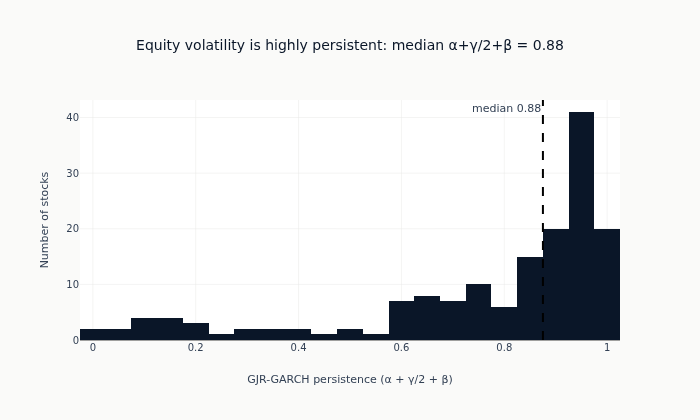

In [12]:
if persist_df is not None and median_persist is not None:
    fig = go.Figure()
    fig.add_histogram(
        x=persist_df["persistence"].to_list(),
        marker_color=ml4t_palette(1)[0],
        nbinsx=30,
    )
    fig.add_vline(
        x=median_persist,
        line_width=2,
        line_dash="dash",
        line_color="black",
        annotation_text=f"median {median_persist:.2f}",
        annotation_position="top left",
    )
    fig.update_layout(
        title=f"Equity volatility is highly persistent: median α+γ/2+β = {median_persist:.2f}",
        xaxis_title="GJR-GARCH persistence (α + γ/2 + β)",
        yaxis_title="Number of stocks",
        height=420,
    )
    fig.show()

The success rate indicates how many symbol-fold combinations produced valid
GARCH estimates. Failures typically occur for stocks with insufficient history
(new listings) or extreme return patterns that prevent convergence. Downstream
models should treat missing GARCH features as informative (potentially a quality signal).

In [13]:
# Combine all fold results
if all_garch_results:
    garch_df = pl.concat(all_garch_results).sort(["symbol", "timestamp"])
    print(f"Total GARCH forecasts: {len(garch_df):,} rows, {garch_df['symbol'].n_unique()} symbols")
else:
    print("No GARCH results - creating empty DataFrame")
    garch_df = pl.DataFrame(
        {
            "timestamp": pl.Series([], dtype=pl.Date),
            "symbol": pl.Series([], dtype=pl.Utf8),
            "garch_cond_vol": pl.Series([], dtype=pl.Float64),
            "fold": pl.Series([], dtype=pl.Int32),
        }
    )

Total GARCH forecasts: 1,091,740 rows, 562 symbols


## 5. Compute Derived Features

Using the GARCH conditional volatility, compute:
- `garch_ivrv_spread`: IV - GARCH forecast (forward-looking VRP)
- `garch_vol_surprise`: |return| / GARCH forecast (news impact)

In [14]:
# Add daily returns for vol surprise
returns = (
    prices.sort(["symbol", "timestamp"])
    .with_columns(pl.col("close").pct_change().over("symbol").alias("_daily_ret"))
    .select(["timestamp", "symbol", "_daily_ret"])
)

temporal = garch_df.join(returns, on=["timestamp", "symbol"], how="left")

# Vol surprise: |actual return| / predicted vol
temporal = temporal.with_columns(
    (
        pl.col("_daily_ret").abs()
        / pl.col("garch_cond_vol").clip(lower_bound=0.001)
        * (252**0.5)  # Annualize daily return for comparison
    ).alias("garch_vol_surprise")
)

# Forward-looking VRP: IV - GARCH conditional vol
if has_iv and ch8_features is not None:
    temporal = temporal.join(ch8_features, on=["timestamp", "symbol"], how="left")
    temporal = temporal.with_columns(
        (pl.col("iv_30_atm") - pl.col("garch_cond_vol")).alias("garch_ivrv_spread")
    ).drop("iv_30_atm")
    print("Computed garch_ivrv_spread (forward-looking VRP)")
else:
    print("Skipping garch_ivrv_spread (no Ch8 IV data available)")

# Drop intermediate columns
temporal = temporal.drop("_daily_ret")

print(f"\nTemporal features: {temporal.shape}")
print(f"Columns: {temporal.columns}")

Computed garch_ivrv_spread (forward-looking VRP)

Temporal features: (1091740, 6)
Columns: ['timestamp', 'garch_cond_vol', 'symbol', 'fold', 'garch_vol_surprise', 'garch_ivrv_spread']


## 6. Feature Summary

In [15]:
feat_cols = [c for c in temporal.columns if c not in ("timestamp", "symbol", "fold")]
summary_rows = []
for col in feat_cols:
    stats = temporal.select(
        pl.col(col).is_not_null().sum().alias("n_valid"),
        pl.col(col).mean().alias("mean"),
        pl.col(col).std().alias("std"),
        pl.col(col).median().alias("median"),
    ).row(0, named=True)
    stats["feature"] = col
    stats["coverage_pct"] = round(stats["n_valid"] / max(len(temporal), 1) * 100, 1)
    summary_rows.append(stats)

summary_df = pl.DataFrame(summary_rows).select(
    "feature", "n_valid", "coverage_pct", "mean", "std", "median"
)
print(summary_df)

shape: (3, 6)
┌────────────────────┬─────────┬──────────────┬───────────┬──────────┬──────────┐
│ feature            ┆ n_valid ┆ coverage_pct ┆ mean      ┆ std      ┆ median   │
│ ---                ┆ ---     ┆ ---          ┆ ---       ┆ ---      ┆ ---      │
│ str                ┆ i64     ┆ f64          ┆ f64       ┆ f64      ┆ f64      │
╞════════════════════╪═════════╪══════════════╪═══════════╪══════════╪══════════╡
│ garch_cond_vol     ┆ 1091740 ┆ 100.0        ┆ 0.300863  ┆ 0.197567 ┆ 0.255299 │
│ garch_vol_surprise ┆ 1091740 ┆ 100.0        ┆ 0.747978  ┆ 0.795298 ┆ 0.556332 │
│ garch_ivrv_spread  ┆ 838618  ┆ 76.8         ┆ -0.009982 ┆ 0.164129 ┆ 0.001907 │
└────────────────────┴─────────┴──────────────┴───────────┴──────────┴──────────┘


### Downstream Merge Strategy

Temporal features cover **both train and test periods** for each fold. GARCH
parameters are fitted on training data only, then `model.fix()` runs the
variance recursion over the full train+test window with frozen parameters.
This means conditional vol estimates for the training period use only the
model's own parameters (no re-estimation), providing valid features for
downstream model training.

The `fold` column is preserved in `model_based.parquet` so downstream
consumers can join per-fold features correctly.

Downstream consumers (Ch11+ models) should:
- **Left-join** `model_based.parquet` onto `financial.parquet` by
  `[timestamp, symbol, fold]`
- The `fold` column ensures each CV fold gets its own GARCH features
  (fitted on that fold's training window)
- **Ablation test**: compare model performance with and without temporal features
  to isolate their incremental contribution

## 7. Save Temporal Features

In [16]:
FEATURES_DIR.mkdir(parents=True, exist_ok=True)

output_path = FEATURES_DIR / "model_based.parquet"
temporal.write_parquet(output_path)
print(f"Saved model_based.parquet ({output_path.stat().st_size / 1024:.1f} KB)")
print(f"  Shape: {temporal.shape}")

Saved model_based.parquet (22587.6 KB)
  Shape: (1091740, 6)


## 8. Incremental Evaluation

Compute IC for temporal features against the primary label (5d forward return).
Compare static VRP (`ivrv_spread` from Ch8) vs dynamic VRP (`garch_ivrv_spread`)
to test whether GARCH improves the VRP signal.

**Context**: Ch8 feature evaluation found weak individual signal strength
(no features survive FDR at 5%). The temporal features attempt to improve
the VRP signal specifically.

**Scope of this evaluation**: the IC below uses only each canonical validation
fold. It selects or drops **no** feature - all three temporal features are
written to `model_based.parquet` in section 7 before this diagnostic runs. The
authoritative feature evaluation remains `05_evaluation.py`; this section only
characterizes the dynamic-vs-static VRP comparison without touching the holdout.

In [17]:
from ml4t.diagnostic.metrics import compute_ic_hac_stats, cross_sectional_ic_series

# Load primary label
label_path = CASE_DIR / "labels" / "fwd_ret_5d.parquet"
if label_path.exists() and len(temporal) > 0:
    label_df = pl.read_parquet(label_path)
    label_col = "fwd_ret_5d"

    validation_parts = [
        temporal.filter(
            (pl.col("fold") == split["fold"])
            & (pl.col("timestamp") >= split["val_start"])
            & (pl.col("timestamp") <= split["val_end"])
        )
        for split in canonical_splits
    ]
    validation_temporal = pl.concat(validation_parts).sort(["timestamp", "symbol"])
    if validation_temporal.n_unique(["timestamp", "symbol"]) != len(validation_temporal):
        raise RuntimeError("Canonical validation GARCH keys are not unique")

    temporal_eval = validation_temporal.join(
        label_df.rename({label_col: "forward_return"}),
        on=["timestamp", "symbol"],
        how="inner",
    )

    temporal_ic_results = []
    temp_feat_cols = [c for c in temporal.columns if c not in ("timestamp", "symbol", "fold")]
    for feat in temp_feat_cols:
        feat_eval = temporal_eval.select(
            ["timestamp", "symbol", feat, "forward_return"]
        ).drop_nulls()
        if len(feat_eval) < 100:
            continue
        feat_eval = feat_eval.rename({feat: "prediction"})
        ic_series = cross_sectional_ic_series(
            feat_eval,
            feat_eval,
            date_col="timestamp",
            entity_col="symbol",
            method="spearman",
            min_obs=10,
        )
        if len(ic_series) > 10:
            hac_stats = compute_ic_hac_stats(ic_series)
            temporal_ic_results.append(
                {
                    "name": feat,
                    "ic_mean": round(hac_stats["mean_ic"], 4),
                    "hac_tstat": round(hac_stats["t_stat"], 2),
                    "hac_pval": round(hac_stats["p_value"], 4),
                }
            )

    print("Temporal feature IC (vs fwd_ret_5d):")
    for r in temporal_ic_results:
        print(f"  {r['name']:25s}: IC={r['ic_mean']:.4f}, t={r['hac_tstat']:.2f}")

    # Compare static vs dynamic VRP
    base_features_path = FEATURES_DIR / "financial.parquet"
    if base_features_path.exists():
        base = _normalize_symbol_column(pl.read_parquet(base_features_path)).select(
            ["timestamp", "symbol", "ivrv_spread"]
        )
        validation_start = min(split["val_start"] for split in canonical_splits)
        validation_end = max(split["val_end"] for split in canonical_splits)
        static_eval = (
            base.filter(
                (pl.col("timestamp") >= validation_start) & (pl.col("timestamp") <= validation_end)
            )
            .join(
                label_df.rename({label_col: "forward_return"}),
                on=["timestamp", "symbol"],
                how="inner",
            )
            .drop_nulls()
        )
        static_eval = static_eval.rename({"ivrv_spread": "prediction"})
        static_ic = cross_sectional_ic_series(
            static_eval,
            static_eval,
            date_col="timestamp",
            entity_col="symbol",
            method="spearman",
            min_obs=10,
        )
        if len(static_ic) > 10:
            static_hac = compute_ic_hac_stats(static_ic)
            static_ic_mean = round(static_hac["mean_ic"], 4)
            static_tstat = round(static_hac["t_stat"], 2)
        else:
            static_ic_mean, static_tstat = 0, 0

        dynamic_r = next((r for r in temporal_ic_results if r["name"] == "garch_ivrv_spread"), None)
        dynamic_ic_mean = dynamic_r["ic_mean"] if dynamic_r else 0
        dynamic_tstat = dynamic_r["hac_tstat"] if dynamic_r else 0

        print("\nStatic vs Dynamic VRP:")
        print(f"  Static (ivrv_spread):     IC={static_ic_mean:.4f}, t={static_tstat:.2f}")
        print(f"  Dynamic (garch_ivrv):     IC={dynamic_ic_mean:.4f}, t={dynamic_tstat:.2f}")
        print(f"  Improvement:              {abs(dynamic_ic_mean) - abs(static_ic_mean):.4f}")
    else:
        static_ic_mean, static_tstat = 0, 0
        dynamic_ic_mean, dynamic_tstat = 0, 0
else:
    temporal_ic_results = []
    static_ic_mean = static_tstat = dynamic_ic_mean = dynamic_tstat = 0
    print("Skipping incremental evaluation (label or temporal data not available)")

Temporal feature IC (vs fwd_ret_5d):
  garch_cond_vol           : IC=-0.0064, t=-0.34
  garch_vol_surprise       : IC=0.0020, t=0.36
  garch_ivrv_spread        : IC=-0.0008, t=-0.09



Static vs Dynamic VRP:
  Static (ivrv_spread):     IC=0.0019, t=0.17
  Dynamic (garch_ivrv):     IC=-0.0008, t=-0.09
  Improvement:              -0.0011


The chart ranks the three temporal features by their standalone information
coefficient against the 5-day forward return. Consistent with the Ch8 finding,
the individual signal is weak: the GARCH features earn their place as an input
to the multivariate models downstream, not as a standalone alpha.

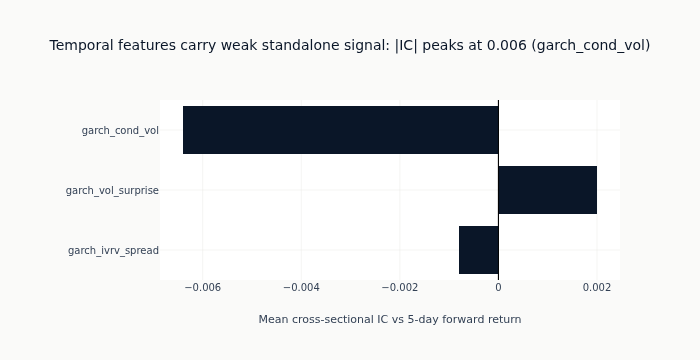

In [18]:
if temporal_ic_results:
    ic_sorted = sorted(temporal_ic_results, key=lambda r: abs(r["ic_mean"]), reverse=True)
    _best = ic_sorted[0]
    fig = go.Figure()
    fig.add_bar(
        x=[r["ic_mean"] for r in ic_sorted],
        y=[r["name"] for r in ic_sorted],
        orientation="h",
        marker_color=ml4t_palette(1)[0],
    )
    fig.add_vline(x=0.0, line_width=1, line_color="black")
    fig.update_layout(
        title=(
            f"Temporal features carry weak standalone signal: "
            f"|IC| peaks at {abs(_best['ic_mean']):.3f} ({_best['name']})"
        ),
        xaxis_title="Mean cross-sectional IC vs 5-day forward return",
        yaxis_title=None,
        yaxis=dict(autorange="reversed"),
        margin=dict(l=160),
        height=360,
    )
    fig.show()

The key test for this notebook: does the GARCH conditional-vol denominator
improve the variance-risk-premium signal over the backward-looking realized-vol
denominator from Ch8? The chart compares the two VRP variants' |IC| head to head.

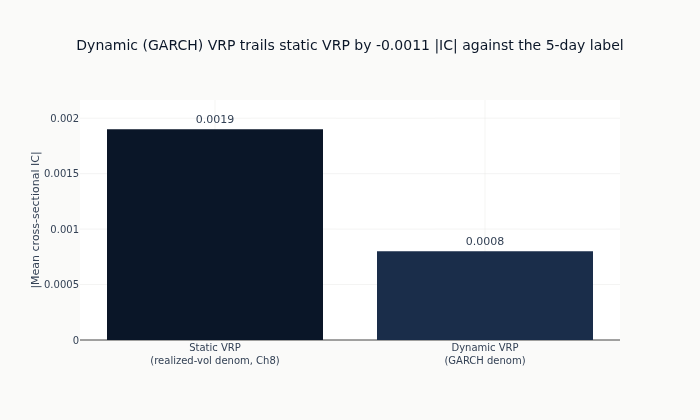

In [19]:
if temporal_ic_results and (static_ic_mean or dynamic_ic_mean):
    _improve = abs(dynamic_ic_mean) - abs(static_ic_mean)
    _verb = "beats" if _improve > 0 else "trails"
    fig = go.Figure()
    fig.add_bar(
        x=["Static VRP<br>(realized-vol denom, Ch8)", "Dynamic VRP<br>(GARCH denom)"],
        y=[abs(static_ic_mean), abs(dynamic_ic_mean)],
        marker_color=[ml4t_palette(2)[0], ml4t_palette(2)[1]],
        text=[f"{abs(static_ic_mean):.4f}", f"{abs(dynamic_ic_mean):.4f}"],
        textposition="outside",
    )
    fig.update_layout(
        title=(
            f"Dynamic (GARCH) VRP {_verb} static VRP by {_improve:+.4f} |IC| "
            f"against the 5-day label"
        ),
        yaxis_title="|Mean cross-sectional IC|",
        xaxis_title=None,
        height=420,
    )
    fig.show()

## Key Takeaways

1. **The GARCH denominator does not improve the VRP signal here**: the dynamic
   feature's |IC| is 0.0008, below 0.0019 for Ch8's static `ivrv_spread`. Neither
   variant is significant on its own (HAC t well below 2), consistent with the Ch8
   result that no single feature carries a standalone edge. The GARCH features enter
   the downstream multivariate models as candidate inputs, not as lone signals.

2. **Walk-forward discipline**: GARCH is fitted only on training data for
   each CV fold. The variance recursion runs on the full train+test window
   with frozen parameters, providing features for both periods without
   look-ahead bias.

3. **Minimal scope by design**: Only 3 features (cond_vol, ivrv_spread,
   vol_surprise) -- this case study's value is in options-derived features
   (Ch8), not temporal dynamics.

4. **GJR asymmetry matters for equities**: The leverage effect (negative
   returns increase vol more than positive) is well-documented and directly
   relevant because the VRP is larger after negative shocks. The fitted
   persistence sits just below 1.0, confirming slow-decaying, forecastable
   volatility.

**Next**: Ch11+ models combine Ch8 features with these temporal features and
run the ablation that isolates their incremental contribution.